In [ ]:
import numpy as np
import tensorflow as tf
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



In [ ]:
corpus = """
Volleyball is a popular team sport played between two teams separated by a net.

Each team tries to send the ball over the net and ground it on the opponent’s court while preventing the same on their side.

A standard game is played with six players on each team, though beach volleyball is played with two players per side.

The game begins with a serve, and players use their hands, forearms, or any part of the body to hit the ball without catching or holding it.

Matches are usually played in sets, and the first team to reach 25 points with at least a two-point lead wins the set.

Volleyball improves physical fitness, agility, and hand–eye coordination.

It also teaches teamwork, communication, and strategic thinking.

The sport can be played indoors, on the beach, or even on grass courts.

It is enjoyed recreationally and competitively at school, college, national, and international levels.

Volleyball is governed internationally by the Fédération Internationale de Volleyball (FIVB).

Major tournaments include the Olympic Games, World Championships, and World Cup.

The game’s fast pace and exciting rallies make it thrilling for both players and spectators.
"""

In [ ]:
# Cleaning : lowercase, remove punctuation
data = corpus.lower()
data = re.sub(r'[^a-zA-z0-9\s]', '', data)
data = re.sub(r'\s+', ' ', data).strip()
print(data)

volleyball is a popular team sport played between two teams separated by a net each team tries to send the ball over the net and ground it on the opponents court while preventing the same on their side a standard game is played with six players on each team though beach volleyball is played with two players per side the game begins with a serve and players use their hands forearms or any part of the body to hit the ball without catching or holding it matches are usually played in sets and the first team to reach 25 points with at least a twopoint lead wins the set volleyball improves physical fitness agility and handeye coordination it also teaches teamwork communication and strategic thinking the sport can be played indoors on the beach or even on grass courts it is enjoyed recreationally and competitively at school college national and international levels volleyball is governed internationally by the fdration internationale de volleyball fivb major tournaments include the olympic ga

In [ ]:
# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts([data])
total_words = len(tokenizer.word_index) + 1

print(f"Total unique words: {total_words}")
print(f"Word index map: {tokenizer.word_index}")


Total unique words: 118
Word index map: {'the': 1, 'and': 2, 'volleyball': 3, 'is': 4, 'a': 5, 'played': 6, 'it': 7, 'on': 8, 'team': 9, 'with': 10, 'players': 11, 'to': 12, 'or': 13, 'sport': 14, 'two': 15, 'by': 16, 'net': 17, 'each': 18, 'ball': 19, 'their': 20, 'side': 21, 'game': 22, 'beach': 23, 'at': 24, 'games': 25, 'world': 26, 'popular': 27, 'between': 28, 'teams': 29, 'separated': 30, 'tries': 31, 'send': 32, 'over': 33, 'ground': 34, 'opponents': 35, 'court': 36, 'while': 37, 'preventing': 38, 'same': 39, 'standard': 40, 'six': 41, 'though': 42, 'per': 43, 'begins': 44, 'serve': 45, 'use': 46, 'hands': 47, 'forearms': 48, 'any': 49, 'part': 50, 'of': 51, 'body': 52, 'hit': 53, 'without': 54, 'catching': 55, 'holding': 56, 'matches': 57, 'are': 58, 'usually': 59, 'in': 60, 'sets': 61, 'first': 62, 'reach': 63, '25': 64, 'points': 65, 'least': 66, 'twopoint': 67, 'lead': 68, 'wins': 69, 'set': 70, 'improves': 71, 'physical': 72, 'fitness': 73, 'agility': 74, 'handeye': 75, 'c

In [ ]:
# Create N-gram sequences
input_sequences = []
token_list = tokenizer.texts_to_sequences([data])[0]

for i in range(1, len(token_list)):
    n_gram_sequence = token_list[:i+1]
    input_sequences.append(n_gram_sequence)

#pad sequences to uniform length
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# Create predictors(X) and labal(y)
X, y = input_sequences[:, :-1], input_sequences[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print(f"Max sequence length: {max_sequence_len}")
print(f"Input shape: {X.shape}")
print(f"Label shape: {y.shape}")


Max sequence length: 189
Input shape: (188, 188)
Label shape: (188, 118)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
#Paramenters
embedding_dim = 100
hidden_units = 128
epochs = 200

def build_model(model_type):
  model = Sequential()
  model.add(Embedding(total_words, embedding_dim, input_length=max_sequence_len-1))

  if model_type == 'RNN':
    model.add(SimpleRNN(hidden_units))
  elif model_type == 'LSTM':
    model.add(LSTM(hidden_units))
  elif model_type == 'GRU':
    model.add(GRU(hidden_units))

  model.add(Dense(total_words, activation='softmax'))
  model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])
  return model


In [ ]:
#Initialize models
model_rnn = build_model('RNN')
model_lstm = build_model('LSTM')
model_gru = build_model('GRU')

#Train all the models
print('Training RNN...')
hist_rnn = model_rnn.fit(X, y, epochs=epochs, verbose=0)
print('Training LSTM...')
hist_lstm = model_lstm.fit(X, y, epochs=epochs, verbose=0)
print('Training GRU...')
hist_gru = model_gru.fit(X, y, epochs=epochs, verbose=0)

print("Training complete!")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training RNN...
Training LSTM...
Training GRU...
Training complete!


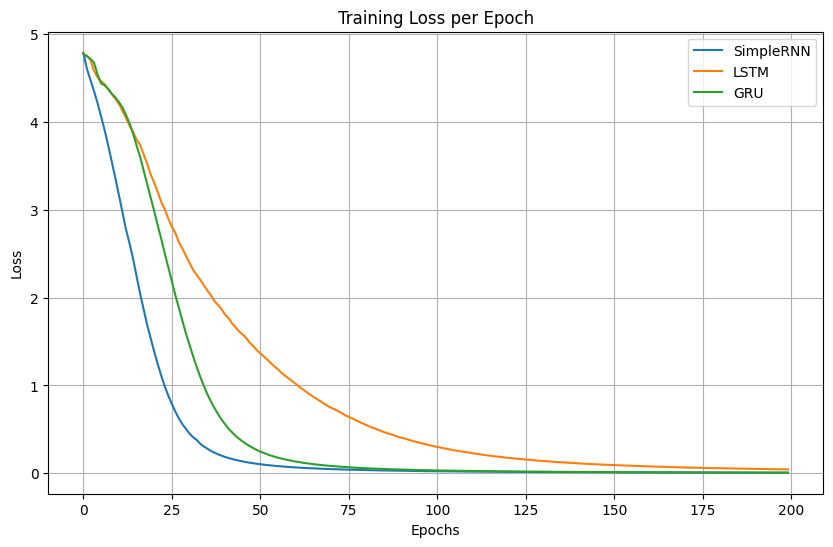

In [ ]:
# visualize Training Trajectories
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(hist_rnn.history['loss'], label='SimpleRNN')
plt.plot(hist_lstm.history['loss'], label='LSTM')
plt.plot(hist_gru.history['loss'], label='GRU')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
# Text generation logic to generate 10 words

def generate_text(seed_text, next_words, model, max_sequence_len):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')

        #Predict the next word
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text


In [ ]:
# Example
seed_prompt = "Volleyball is"
print("RNN Generation:", generate_text(seed_prompt, 10, model_rnn, max_sequence_len))
print("LSTM Generation:", generate_text(seed_prompt, 10, model_lstm, max_sequence_len))
print("GRU Generation:", generate_text(seed_prompt, 10, model_gru, max_sequence_len))


RNN Generation: Volleyball is a popular team sport played between two teams separated by
LSTM Generation: Volleyball is a popular team sport played between two teams separated by
GRU Generation: Volleyball is a popular team sport played between two teams separated by
